In [4]:
import pystac_client
from pystac_client import Client
import dask
import stackstac
from rasterio.enums import Resampling
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show
import pandas as pd

In [5]:
api_url = "https://earth-search.aws.element84.com/v1"

In [6]:
client = Client.open(api_url)

In [7]:
collections = client.get_collections()

In [8]:
for collection in collections:
    print(collection)

<CollectionClient id=sentinel-2-pre-c1-l2a>
<CollectionClient id=cop-dem-glo-30>
<CollectionClient id=naip>
<CollectionClient id=cop-dem-glo-90>
<CollectionClient id=landsat-c2-l2>
<CollectionClient id=sentinel-2-l2a>
<CollectionClient id=sentinel-2-l1c>
<CollectionClient id=sentinel-2-c1-l2a>
<CollectionClient id=sentinel-1-grd>


In [9]:
tile_list_path = './sentinel_2_tiles.csv'
s2_tiles = pd.read_csv(tile_list_path)

In [10]:
s2_tiles

,tile
0,22WEA
1,22WEB
2,22WEC
3,22WED
4,22WEE
5,22WFA
6,22WFB
7,22WFC


In [11]:
date_range = "2020-05-01/2025-08-31" 
# Cloud cover filter: less than 10%
cloud_cover_max = 10 

In [58]:
search_results = client.search(
    collections=["sentinel-2-c1-l2a"], #sentinel-2-l1c
    intersects=point,
    datetime=date_range,
    query={"eo:cloud_cover": {"lt": cloud_cover_max}, 
          "s2:mgrs_tile": {"eq": "22WEB"} },
    sortby=["+properties.eo:cloud_cover"]

)

In [59]:
print(search_results.matched())

13


In [60]:
items = search_results.item_collection()

In [61]:
len(items)

12

In [62]:
for item in items:
    print(item.properties["eo:cloud_cover"])

0.136798
0.258257
0.516819
0.917615
1.370314
1.569299
2.049985
2.983623
5.975441
6.3965
6.818248
7.931276


In [63]:
#Let's look at the second item:
selected_item = items[4]

<Item id=S2A_T22WEB_20250609T153302_L2A>

In [67]:
blue_href = selected_item.assets['blue'].href
red_href = selected_item.assets['red'].href
green_href = selected_item.assets['green'].href
swir_href = selected_item.assets['swir16'].href

In [68]:
blue_offset = selected_item.assets['blue']
blue_scale = blue_offset.extra_fields['raster:bands'][0]['scale']
blue_offset = blue_offset.extra_fields['raster:bands'][0]['offset']
blue_offset

-0.1

In [69]:
red_offset = selected_item.assets['red']
red_scale = red_offset.extra_fields['raster:bands'][0]['scale']
red_offset = red_offset.extra_fields['raster:bands'][0]['offset']
red_scale

0.0001

In [70]:
swir_offset = selected_item.assets['swir16']
swir_scale = swir_offset.extra_fields['raster:bands'][0]['scale']
swir_offset = swir_offset.extra_fields['raster:bands'][0]['offset']
swir_offset

-0.1

In [71]:
selected_item.properties['s2:product_uri'].split('.')[0]

'S2A_MSIL2A_20250609T153301_N0511_R111_T22WEB_20250609T200811'

In [123]:
with rasterio.open(blue_href, mode='r') as src_b:
    blue_band = src_b.read(1).astype(np.float32)
    blue_reflect = blue_band * blue_scale + blue_offset
    blue_scale_test = src_b.scales[0]
    blue_scale_offset = src_b.offsets[0]
    
with rasterio.open(red_href, mode='r') as src_r:
    red_band = src_r.read(1).astype(np.float32)
    red_reflect = red_band * blue_scale + blue_offset

with rasterio.open(green_href, mode='r') as src_g:
    green_band = src_g.read(1).astype(np.float32)
    green_reflect = green_band * blue_scale + blue_offset
    
    profile = src_g.profile

In [124]:
blue_href

'https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/22/W/EB/2025/6/S2A_T22WEB_20250609T153302_L2A/B02.tif'

In [125]:
blue_scale_offset

-0.1

In [126]:
upscale_factor = 2
with rasterio.open(swir_href, mode='r') as src_sw:
    swir_band = src_sw.read(1, 
                            out_shape=(
                            src_sw.count,
                            int(src_sw.height * upscale_factor),
                            int(src_sw.width * upscale_factor)
                            ),
                            resampling=Resampling.bilinear).astype(np.float64)
    swir_reflect = swir_band * blue_scale + blue_offset

In [127]:
swir_band.shape

(10980, 10980)

In [128]:
np.nanmin(red_band)

np.float32(0.0)

In [140]:
ndsi = (green_reflect - swir_reflect) / (green_reflect + swir_reflect)
ndwi = (blue_reflect - red_reflect) / (blue_reflect + red_reflect)

ndsi_mask = ndsi > 0.85
blue_mask = blue_reflect > 0.4
ndwi_mask = ndwi > 0.3 # 0.5 is dunmire 2021 value

combined_mask = blue_mask & ndsi_mask & ndwi_mask
# ndwi_filter_masked = np.where(combined_mask, ndwi, np.nan)
# ndwi_filter = np.where(ndwi>=0.5, ndwi ,np.nan)
lake_pixels = np.where(combined_mask, ndwi, np.nan)

In [130]:
np.nanmin(ndwi_filter)

np.float64(0.5)

In [131]:
np.nanmin(blue_reflect)

np.float32(-0.1)

In [132]:
profile

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 10980, 'height': 10980, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 22N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32622"]]'), 'transform': Affine(10.0, 0.0, 499980.0,
       0.0, -10.0, 7700040.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}

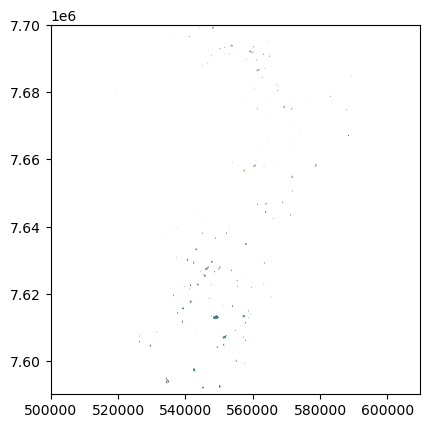

<Axes: >

In [133]:
show(lake_pixels, transform=src_rgb.transform, adjust=False)


In [135]:
print(lake_pixels.dtype)
profile_lake_pixels = profile.copy()
profile_lake_pixels['dtype'] = 'float32'

float32


In [144]:
# with rasterio.open('./lakes_f32_S3_ndwi_03.tif', mode='w', **profile_lake_pixels) as dst:
#         dst.write(lake_pixels, 1)

# make lake binary
lake_pixels_zero_binary = np.where(np.isnan(lake_pixels), 0, 1)
with rasterio.open('./lakes_f32_S3_ndwi_03_zero_binary.tif', mode='w', **profile_lake_pixels) as dst:
        dst.write(lake_pixels_zero_binary, 1)

In [139]:
# with rasterio.open('./blue_band.tif', mode='w', **profile_lake_pixels) as dst:
#     dst.write(blue_reflect, 1)
#     dst.set_band_description(1, 'blue')

with rasterio.open('./ndwi_band.tif', mode='w', **profile_lake_pixels) as dst:
    dst.write(ndwi, 1)
    dst.set_band_description(1, 'ndwi')

In [106]:
profile_rgb = profile.copy()
profile_rgb['count'] = 3
profile_rgb['dtype'] = 'float32'

In [103]:
profile_rgb

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': 0.0, 'width': 10980, 'height': 10980, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 22N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32622"]]'), 'transform': Affine(10.0, 0.0, 499980.0,
       0.0, -10.0, 7700040.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}

In [104]:
rgb_bands = [red_reflect, green_reflect, blue_reflect]
rbg_names = ['red', 'green', 'blue']

In [105]:
with rasterio.open('./test_lake_RGB_S3_reflection_L2A_f64.tif', mode='w', **profile_rgb) as dst:
    for band_num, band in enumerate(rgb_bands):
        
        dst.write(band, band_num+1) # Write the data to band 1
        dst.set_band_description(band_num+1, rbg_names[band_num])

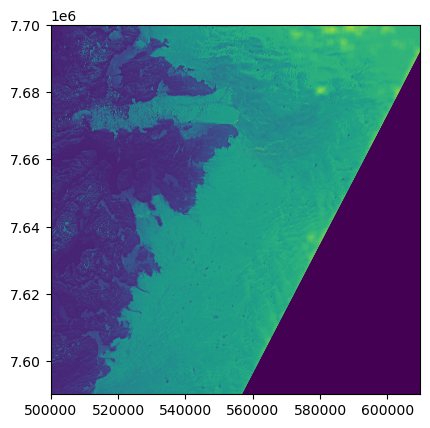

<Axes: >

In [101]:
show(blue_reflect, transform=src_r.transform)

In [96]:
src_r.transform

Affine(10.0, 0.0, 499980.0,
       0.0, -10.0, 7700040.0)

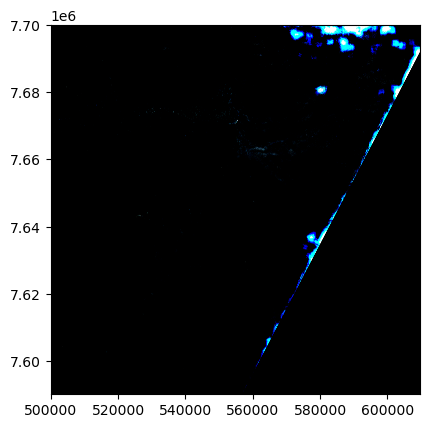

In [99]:
with rasterio.open('./test_lake_RGB_S3_reflection_L2A.tif', mode='r') as src_rgb:
    show(src_rgb.read(), transform=src_rgb.transform, adjust=True)